

## **┗ EDA about Casting dataset**
---

<img src="https://www.longshengmfg.com/wp-content/uploads/2024/05/1041-1.jpg" width="500" height="300">

> **About Data**

* dataset link : https://www.kamp-ai.kr/aidataDetail?AI_SEARCH=%EC%A3%BC%EC%A1%B0&page=1&DATASET_SEQ=53&EQUIP_SEL=&GUBUN_SEL=&FILE_TYPE_SEL=&WDATE_SEL=
* Dataset Description
    * **Casting** is a manufacturing process where metals (such as iron, aluminum alloys, copper, etc.) are melted and poured into molds to solidify, making it suitable for creating detailed and complex shapes and ideal for mass production.
    * Types of casting include die casting (metal molds), sand casting (sand molds), and shell casting (cell molds).
    * **Die casting** is a process where molten metal is forcibly injected into a metal mold (die), primarily using aluminum alloys, copper alloys, and magnesium alloys. The advantages of die casting include high precision, low cost, and fast production speed.
    * Key factors in die casting include the management of `pressure`, `speed`, `time`, and `temperature.`

* 📍The primary analysis goal is to classify pass or fail outcomes by analyzing various key factors.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import scipy
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

os.chdir("/content/drive/MyDrive/(2024-2) 전자제조데이터분석")

df = pd.read_csv('data.csv', encoding='cp949', index_col=0)
df.head()

Mounted at /content/drive


,line,name,mold_name,time,date,count,working,emergency_stop,molten_temp,facility_operation_cycleTime,...,lower_mold_temp3,sleeve_temperature,physical_strength,Coolant_temperature,EMS_operation_time,registration_time,passorfail,tryshot_signal,mold_code,heating_furnace
0,전자교반 3라인 2호기,TM Carrier RH,TM Carrier RH-Semi-Solid DIE-06,2019-01-02,16:45:06,258,가동,ON,731.0,119,...,1449.0,550.0,700.0,34.0,23,2019-01-02 16:45:06,0.0,NaN,8722,NaN
1,전자교반 3라인 2호기,TM Carrier RH,TM Carrier RH-Semi-Solid DIE-06,2019-01-02,16:45:08,243,가동,ON,720.0,98,...,NaN,481.0,0.0,30.0,25,2019-01-02 16:45:08,0.0,NaN,8412,B
2,전자교반 3라인 2호기,TM Carrier RH,TM Carrier RH-Semi-Solid DIE-06,2019-01-02,16:45:58,244,가동,ON,721.0,98,...,NaN,481.0,0.0,30.0,25,2019-01-02 16:45:58,0.0,NaN,8412,B
3,전자교반 3라인 2호기,TM Carrier RH,TM Carrier RH-Semi-Solid DIE-06,2019-01-02,16:48:03,245,가동,ON,721.0,100,...,NaN,483.0,0.0,30.0,25,2019-01-02 16:48:03,0.0,NaN,8412,B
4,전자교반 3라인 2호기,TM Carrier RH,TM Carrier RH-Semi-Solid DIE-06,2019-01-02,16:50:08,246,가동,ON,721.0,99,...,NaN,486.0,0.0,30.0,25,2019-01-02 16:50:08,0.0,NaN,8412,B


In [ ]:
df.columns

Index(['line', 'name', 'mold_name', 'time', 'date', 'count', 'working',
       'emergency_stop', 'molten_temp', 'facility_operation_cycleTime',
       'production_cycletime', 'low_section_speed', 'high_section_speed',
       'molten_volume', 'cast_pressure', 'biscuit_thickness',
       'upper_mold_temp1', 'upper_mold_temp2', 'upper_mold_temp3',
       'lower_mold_temp1', 'lower_mold_temp2', 'lower_mold_temp3',
       'sleeve_temperature', 'physical_strength', 'Coolant_temperature',
       'EMS_operation_time', 'registration_time', 'passorfail',
       'tryshot_signal', 'mold_code', 'heating_furnace'],
      dtype='object')

> **Variable Description**

|Column|Description|
|:---|:---|
|line|Name of the production line where the product is manufactured|
|name|The name of the product|
|mold_name|The name of the mold used to produce the product|
|time|The date when the data was collected (hours, minutes, seconds)|
|date|The time when the data was collected|
|count|The unique number of the product produced on that specific date,representing the production sequence for each day|
|working|Indicates whether the facility is operational ('Operating' or 'Stopped')|
|emergency_stop|Indicates whether the facility is in an emergency stop state ('ON' or 'OFF')|
|molten_temp|The temperature of the molten metal (molten temperature)|
|facility_operation_CycleTime|The operation cycle time of the facility, indicating how long one cycle of operation took|
|production_CycleTime|The cycle time required to produce one product|
|low_section_speed|The speed during the low-speed section, which refers to the speed at which metal is injected during the low-speed phase of die casting|
|high_section_speed|The speed during the high-speed section, referring to the speed of metal injection during the high-speed phase of die casting|
| molten_volume|The volume of molten metal used for casting|
|cast_pressure|The pressure applied when injecting metal into the mold during casting.
|biscuit_thickness|The thickness of the biscuit, the leftover portion between the product and the mold after casting.
|upper_mold_temp1|The temperature at the first point of the upper mold.
|upper_mold_temp2|The temperature at the second point of the upper mold.
|upper_mold_temp3|The temperature at the third point of the upper mold.
|lower_mold_temp1|The temperature at the first point of the lower mold.
|lower_mold_temp2|The temperature at the second point of the lower mold.
|lower_mold_temp3|The temperature at the third point of the lower mold.
|sleeve_temperature|The temperature of the sleeve (a specific part of the mold).
|physical_strength|The physical strength of the product (or measured force).
|Coolant_temperature|The temperature of the coolant used to rapidly cool the metal after casting.
|EMS_operation_time|The operation time of the electromagnetic stirring equipment.
|registration_time|The time when the data was recorded.
|passorfail|Indicates whether the product passed or failed quality checks (0: Pass, 1: Fail).
|tryshot_signal|The tryshot signal, a signal used under certain conditions during casting.
|mold_code|The code number of the mold used.
|heating_furnace|The name or code of the heating furnace used during production.

---

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92015 entries, 0 to 92014
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   line                          92015 non-null  object 
 1   name                          92015 non-null  object 
 2   mold_name                     92015 non-null  object 
 3   time                          92015 non-null  object 
 4   date                          92015 non-null  object 
 5   count                         92015 non-null  int64  
 6   working                       92014 non-null  object 
 7   emergency_stop                92014 non-null  object 
 8   molten_temp                   89754 non-null  float64
 9   facility_operation_cycleTime  92015 non-null  int64  
 10  production_cycletime          92015 non-null  int64  
 11  low_section_speed             92014 non-null  float64
 12  high_section_speed            92014 non-null  float64
 13  molten

## 1️⃣ summary statistics

### Missing values

In [ ]:
df.isnull().sum().div(len(df))

,0
line,0.000000
name,0.000000
mold_name,0.000000
time,0.000000
date,0.000000
count,0.000000
working,0.000011
emergency_stop,0.000011
molten_temp,0.024572
facility_operation_cycleTime,0.000000


▶️ Variables with more than 30% missing data (`molten_volume`, `tryshot_signal`, `heating_furnace`) are excluded from the analysis.

▶️ Afterward, rows containing missing data will be removed.


In [ ]:
df = df.drop(columns=['molten_volume', 'tryshot_signal','heating_furnace'])
df = df.dropna() # null 값 포함 행 제거

In [ ]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

missing_values

,0
line,0
name,0
mold_name,0
time,0
date,0
count,0
working,0
emergency_stop,0
molten_temp,0
facility_operation_cycleTime,0


In [ ]:
# Remaining columns
df.columns

Index(['line', 'name', 'mold_name', 'time', 'date', 'count', 'working',
       'emergency_stop', 'molten_temp', 'facility_operation_cycleTime',
       'production_cycletime', 'low_section_speed', 'high_section_speed',
       'cast_pressure', 'biscuit_thickness', 'upper_mold_temp1',
       'upper_mold_temp2', 'upper_mold_temp3', 'lower_mold_temp1',
       'lower_mold_temp2', 'lower_mold_temp3', 'sleeve_temperature',
       'physical_strength', 'Coolant_temperature', 'EMS_operation_time',
       'registration_time', 'passorfail', 'mold_code'],
      dtype='object')

In [ ]:
# # Make Week columns for EDA later
# df['datetime'] = pd.to_datetime(df['time'] + ' ' + df['date'])

# # week 별 divide
# start_date = pd.to_datetime('2019-01-02 16:45')
# interval_date = pd.to_datetime('2019-01-09 20:00:00')
# end_date = pd.to_datetime('2019-03-31 23:59:59')
# regular_intervals = pd.date_range(start=interval_date, end='2019-03-24 20:00:00', freq='W')

# date_range = [start_date] + list(regular_intervals) + [end_date]
# df['week'] = pd.cut(df['datetime'], bins=date_range, labels=[str(i) for i in range(1,len(date_range))])
# df.head(3)

---

### Describe
- Describe for numeric variables

In [ ]:
# Extract relevant columns for summary statistics
columns_of_interest = ['facility_operation_cycleTime', 'production_cycletime', 'low_section_speed',
                       'high_section_speed','cast_pressure', 'biscuit_thickness', 'upper_mold_temp1',
                       'upper_mold_temp2', 'upper_mold_temp3','lower_mold_temp1', 'lower_mold_temp2', 'lower_mold_temp3','sleeve_temperature',
                       'physical_strength', 'Coolant_temperature', 'EMS_operation_time','passorfail', 'mold_code']
df['mold_code'] = df['mold_code'].astype('object')

# Extract the main features and target variable
df_main_features = df[columns_of_interest]

# Generate summary statistics for these features
summary_stats = df_main_features.describe()

summary_stats

,facility_operation_cycleTime,production_cycletime,low_section_speed,high_section_speed,cast_pressure,biscuit_thickness,upper_mold_temp1,upper_mold_temp2,upper_mold_temp3,lower_mold_temp1,lower_mold_temp2,lower_mold_temp3,sleeve_temperature,physical_strength,Coolant_temperature,EMS_operation_time,passorfail
count,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000
mean,121.702239,122.318925,110.067922,111.837960,324.527219,50.717881,186.058821,166.520488,1316.772073,204.734484,200.693474,1441.774891,416.044622,703.127101,32.303049,18.279000,0.044186
std,12.169837,12.549906,309.504180,9.646943,27.308033,18.043014,46.343803,31.774197,396.757216,53.716432,44.884524,221.929145,116.456759,308.047352,14.452419,8.433715,0.205508
min,69.000000,0.000000,0.000000,0.000000,41.000000,0.000000,18.000000,15.000000,42.000000,18.000000,20.000000,299.000000,23.000000,0.000000,16.000000,0.000000,0.000000
25%,117.000000,119.000000,110.000000,112.000000,329.000000,47.000000,162.000000,149.000000,1449.000000,166.000000,174.000000,1449.000000,380.000000,697.000000,31.000000,23.000000,0.000000
50%,119.000000,121.000000,110.000000,112.000000,330.000000,50.000000,195.000000,173.000000,1449.000000,210.000000,199.000000,1449.000000,457.000000,703.000000,32.000000,23.000000,0.000000
75%,122.000000,123.000000,110.000000,112.000000,331.000000,53.000000,222.000000,185.000000,1449.000000,251.000000,229.000000,1449.000000,483.000000,710.000000,34.000000,23.000000,0.000000
max,457.000000,482.000000,65535.000000,388.000000,348.000000,422.000000,1449.000000,4232.000000,1449.000000,369.000000,1449.000000,65503.000000,1449.000000,65535.000000,1449.000000,23.000000,1.000000


In [ ]:
df_main_features

,facility_operation_cycleTime,production_cycletime,low_section_speed,high_section_speed,cast_pressure,biscuit_thickness,upper_mold_temp1,upper_mold_temp2,upper_mold_temp3,lower_mold_temp1,lower_mold_temp2,lower_mold_temp3,sleeve_temperature,physical_strength,Coolant_temperature,EMS_operation_time,passorfail,mold_code
0,119,120,110.0,112.0,331.0,35.0,198.0,116.0,1449.0,234.0,316.0,1449.0,550.0,700.0,34.0,23,0.0,8722
22,119,120,109.0,125.0,177.0,48.0,24.0,33.0,1449.0,30.0,273.0,1449.0,479.0,708.0,35.0,23,1.0,8722
24,119,123,109.0,112.0,176.0,49.0,26.0,55.0,1449.0,30.0,323.0,1449.0,513.0,700.0,35.0,23,1.0,8722
26,119,124,109.0,112.0,331.0,47.0,31.0,65.0,1449.0,30.0,343.0,1449.0,531.0,708.0,34.0,23,1.0,8722
28,120,124,110.0,112.0,331.0,46.0,36.0,73.0,1449.0,31.0,343.0,1449.0,544.0,707.0,34.0,23,1.0,8722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,122,122,100.0,101.0,331.0,49.0,83.0,183.0,1449.0,231.0,201.0,1449.0,279.0,726.0,30.0,0,0.0,8917
92011,120,121,100.0,101.0,331.0,54.0,83.0,184.0,1449.0,232.0,201.0,1449.0,279.0,732.0,30.0,0,0.0,8917
92012,122,135,100.0,101.0,331.0,52.0,79.0,184.0,1449.0,225.0,195.0,1449.0,272.0,731.0,30.0,0,0.0,8917
92013,133,122,100.0,101.0,331.0,53.0,82.0,185.0,1449.0,227.0,199.0,1449.0,288.0,723.0,30.0,0,0.0,8917


- Because there are many variables in casting dataset, we construct `RandomForest` model to find appropriate variabels to anlaysis.

In [ ]:
# data split
X = df_main_features.drop(['mold_code','passorfail'], axis=1)
y = df_main_features['passorfail']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# randomforest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

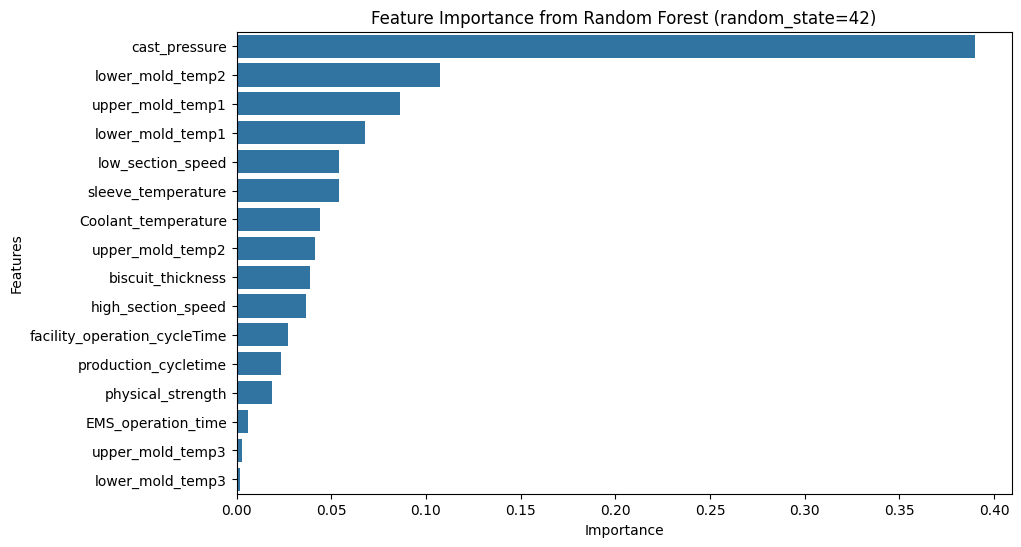

In [ ]:
# feature importances
feature_importances = rf_model.feature_importances_
feature_names = X.columns

# sort descending
sorted_idx = feature_importances.argsort()[::-1]  # 중요도 값을 기준으로 인덱스 정렬 (내림차순)
feature_importances = feature_importances[sorted_idx]  # 중요도 값 정렬
feature_names = feature_names[sorted_idx]  # 특성 이름 정렬

# visualize feature importnaces
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names)
plt.title('Feature Importance from Random Forest (random_state=42)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

- Select the top 5 features as numerical characteristics
    - cast_pressure
    - lower_mold_temp2
    - upper_mold_temp1
    - lower_mold_temp1
    - low_section_speed

---

## 2️⃣ Data Transformation

- Min-max
- Normalization
- Robust Scaling
- box-cox transformation

In [ ]:
#Importing all transformations

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer

In [ ]:
#defining all the transformations

mm_scaler = MinMaxScaler()
sd_scaler = StandardScaler()
rb_scaler = RobustScaler ()
bx_transformer = PowerTransformer(method='box-cox',standardize=False)

### Handling Outliers

Before performing transformation we have to handle the outliers.

In [ ]:
#Checking if there are outliers by describe

features = ['cast_pressure', 'lower_mold_temp2', 'upper_mold_temp1', 'lower_mold_temp1', 'low_section_speed','passorfail']
df[features].describe()

,cast_pressure,lower_mold_temp2,upper_mold_temp1,lower_mold_temp1,low_section_speed,passorfail
count,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000,89441.000000
mean,324.527219,200.693474,186.058821,204.734484,110.067922,0.044186
std,27.308033,44.884524,46.343803,53.716432,309.504180,0.205508
min,41.000000,20.000000,18.000000,18.000000,0.000000,0.000000
25%,329.000000,174.000000,162.000000,166.000000,110.000000,0.000000
50%,330.000000,199.000000,195.000000,210.000000,110.000000,0.000000
75%,331.000000,229.000000,222.000000,251.000000,110.000000,0.000000
max,348.000000,1449.000000,1449.000000,369.000000,65535.000000,1.000000


In [ ]:
# 99.9 / 0.1 percentile method
# Create a copy of the dataframe to preserve the original data
df_filtered = df[features].copy()

# Initialize dictionaries to store UCL and LCL for each column
UCL_dict = {}
LCL_dict = {}

# Initialize a dictionary to store the number of outliers for each column
outliers_count = {}

# Calculate the UCL and LCL for all columns (excluding 'passorfail')
for col in features:
    UCL_dict[col] = np.percentile(df_filtered[col], 99.9)  # Upper Control Limit (99.9th percentile)
    LCL_dict[col] = np.percentile(df_filtered[col], 0.1)   # Lower Control Limit (0.1th percentile)

    # Count how many rows are above UCL or below LCL for the current column
    num_outliers_above = (df_filtered[col] > UCL_dict[col]).sum()
    num_outliers_below = (df_filtered[col] < LCL_dict[col]).sum()

    # Store the total number of outliers for this column
    outliers_count[col] = num_outliers_above + num_outliers_below

    # Print the number of outliers for the current column
    print(f'{col}: {num_outliers_above} above UCL, {num_outliers_below} below LCL')

for col in features:
    df_filtered = df_filtered[(df_filtered[col] >= LCL_dict[col]) & (df_filtered[col] <= UCL_dict[col])]

# Store the initial number of rows
initial_row_count = df_filtered.shape[0]

# Calculate the total number of rows removed
total_rows_removed = initial_row_count - df_filtered.shape[0]

# Print how many rows were removed in total
print(f'Total rows removed after filtering: {total_rows_removed}')

cast_pressure: 90 above UCL, 86 below LCL
lower_mold_temp2: 75 above UCL, 88 below LCL
upper_mold_temp1: 80 above UCL, 81 below LCL
lower_mold_temp1: 89 above UCL, 90 below LCL
low_section_speed: 12 above UCL, 0 below LCL
passorfail: 0 above UCL, 0 below LCL
Total rows removed after filtering: 0


In [ ]:
#After removing outliers
df_filtered.describe()

,cast_pressure,lower_mold_temp2,upper_mold_temp1,lower_mold_temp1,low_section_speed,passorfail
count,88842.000000,88842.000000,88842.000000,88842.000000,88842.00000,88842.000000
mean,324.975788,200.841899,186.331341,204.954188,108.67297,0.041287
std,25.825281,43.317947,45.509058,53.023308,8.29581,0.198954
min,143.000000,44.000000,28.000000,46.000000,0.00000,0.000000
25%,329.000000,174.000000,162.000000,166.000000,110.00000,0.000000
50%,330.000000,199.000000,195.000000,210.000000,110.00000,0.000000
75%,331.000000,229.000000,222.000000,251.000000,110.00000,0.000000
max,338.000000,309.000000,312.000000,363.000000,140.00000,1.000000


### Transformation for numerical variables



#### Min Max Transformation

In [ ]:
#Defining Column names

col_name = ['cast_pressure', 'lower_mold_temp2', 'upper_mold_temp1', 'lower_mold_temp1', 'low_section_speed']
trans_col_name = ['cast_pressure_min_max', 'lower_mold_temp2_min_max', 'upper_mold_temp1_min_max', 'lower_mold_temp1_min_max', 'low_section_speed_min_max']

#Using for loops to perform transformation
for i in range (len(col_name)):
    df_filtered[trans_col_name[i]]= mm_scaler.fit_transform(df_filtered[[col_name[i]]])

#### Normalization

In [ ]:
#Defining Column names
trans_col_name = ['cast_pressure_norm', 'lower_mold_temp2_norm', 'upper_mold_temp1_norm', 'lower_mold_temp1_norm', 'low_section_speed_norm']

#Using for loops to perform transformation
for i in range (len(col_name)):
    df_filtered[trans_col_name[i]]= sd_scaler.fit_transform(df_filtered[[col_name[i]]])

#### Robust Transformation

In [ ]:
#Defining Column names
trans_col_name = ['cast_pressure_rob', 'lower_mold_temp2_rob', 'upper_mold_temp1_rob', 'lower_mold_temp1_rob', 'low_section_speed_rob']

#Using for loops to perform transformation
for i in range (len(col_name)):
  df_filtered[trans_col_name[i]]= rb_scaler.fit_transform(df_filtered[[col_name[i]]])

#### Box-Cox Transformation

In [ ]:
#Defining Column names
trans_col_name = ['cast_pressure_box', 'lower_mold_temp2_box', 'upper_mold_temp1_box', 'lower_mold_temp1_box']

#Using for loops to perform transformation
for i in range (len(trans_col_name)):
    df_filtered[trans_col_name[i]]= bx_transformer.fit_transform(df_filtered[[col_name[i]]])

from sklearn.preprocessing import PowerTransformer  # As an exception, the low_section_speed: Yeo-Johnson transformation (contains 0)

yj_transformer = PowerTransformer(method='yeo-johnson')
df_filtered['low_section_speed_yeo'] = yj_transformer.fit_transform(df_filtered[['low_section_speed']])

### Ordinal Encoder for categorical variables
*이탤릭체 텍스트*

In [ ]:
#importing encoder
!pip install category_encoders
from category_encoders import OrdinalEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 4.5 MB/s eta 0:00:00


In [ ]:
df_filtered['mold_code']=df['mold_code']

In [ ]:
ord_enc = OrdinalEncoder()

In [ ]:
#Performing encoder for the new column
df_filtered['mold_code_ord']=ord_enc.fit_transform(df_filtered['mold_code'])

In [ ]:
#After encoding mold numbers look like this
ord_enc.category_mapping[0]['mapping']

,0
8722.0,1
8573.0,2
8412.0,3
8917.0,4
8600.0,5
8413.0,6
8576.0,7
NaN,-2


## 3️⃣ Data Visualization

### Histogram and Q-Q Plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

def get_hist_and_qq(df, col):  # df_filtered / 보고자 하는 컬럼명 Ex. cast_pressure
  transform_list = ['','_min_max','_norm','_rob','_box']
  if col == 'low_section_speed':
    transform_list = ['','_min_max','_norm','_rob','_yeo']
  col_list = [col+x for x in transform_list]
  temp_df = df[col_list]
  fig, axes = plt.subplots(2,5, figsize=(20,10))
  fig.tight_layout()

  for i, col in enumerate(col_list):
      # Histogram
      if i == 0:
        sns.histplot(temp_df[col], ax=axes[0, i], color='#e99a9a', kde=True)  # 원본 색상만
      else:
        sns.histplot(temp_df[col], ax=axes[0, i], kde=True)
      axes[0, i].set_title(f'{col}')
      axes[0, i].set_xlabel('')
      axes[0, i].set_ylabel('')
      # QQ plot
      probplot(temp_df[col], dist="norm", plot=axes[1, i])
      axes[1, i].set_title('')
      axes[1, i].set_xlabel('')
      axes[1, i].set_ylabel('')

  plt.tight_layout()
  plt.show()

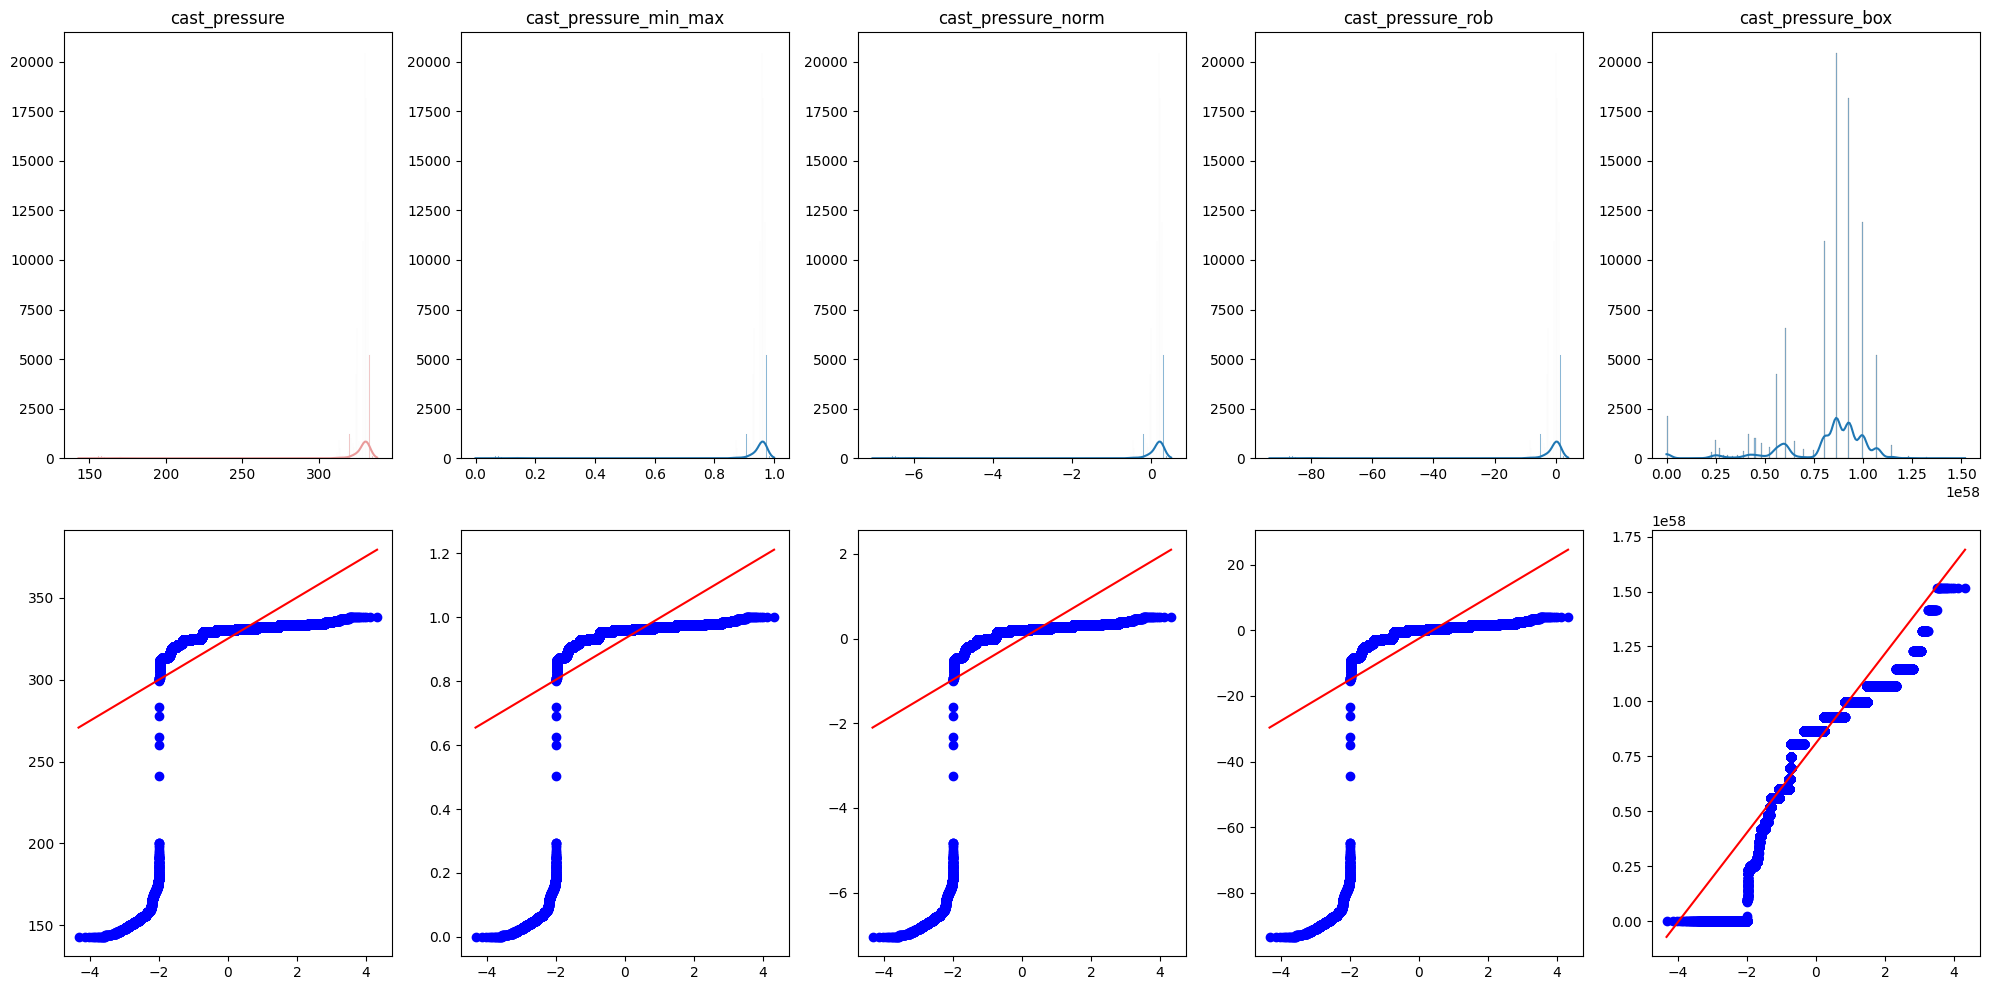

In [ ]:
get_hist_and_qq(df_filtered, 'cast_pressure')

- Since the `Cast pressure` has a distribution skewed to the right, box-cox transformation seems appropriate.
- After box-cox transform, a more even distribution.
- It is closest to a normal distribution in the Q-Q Plot.

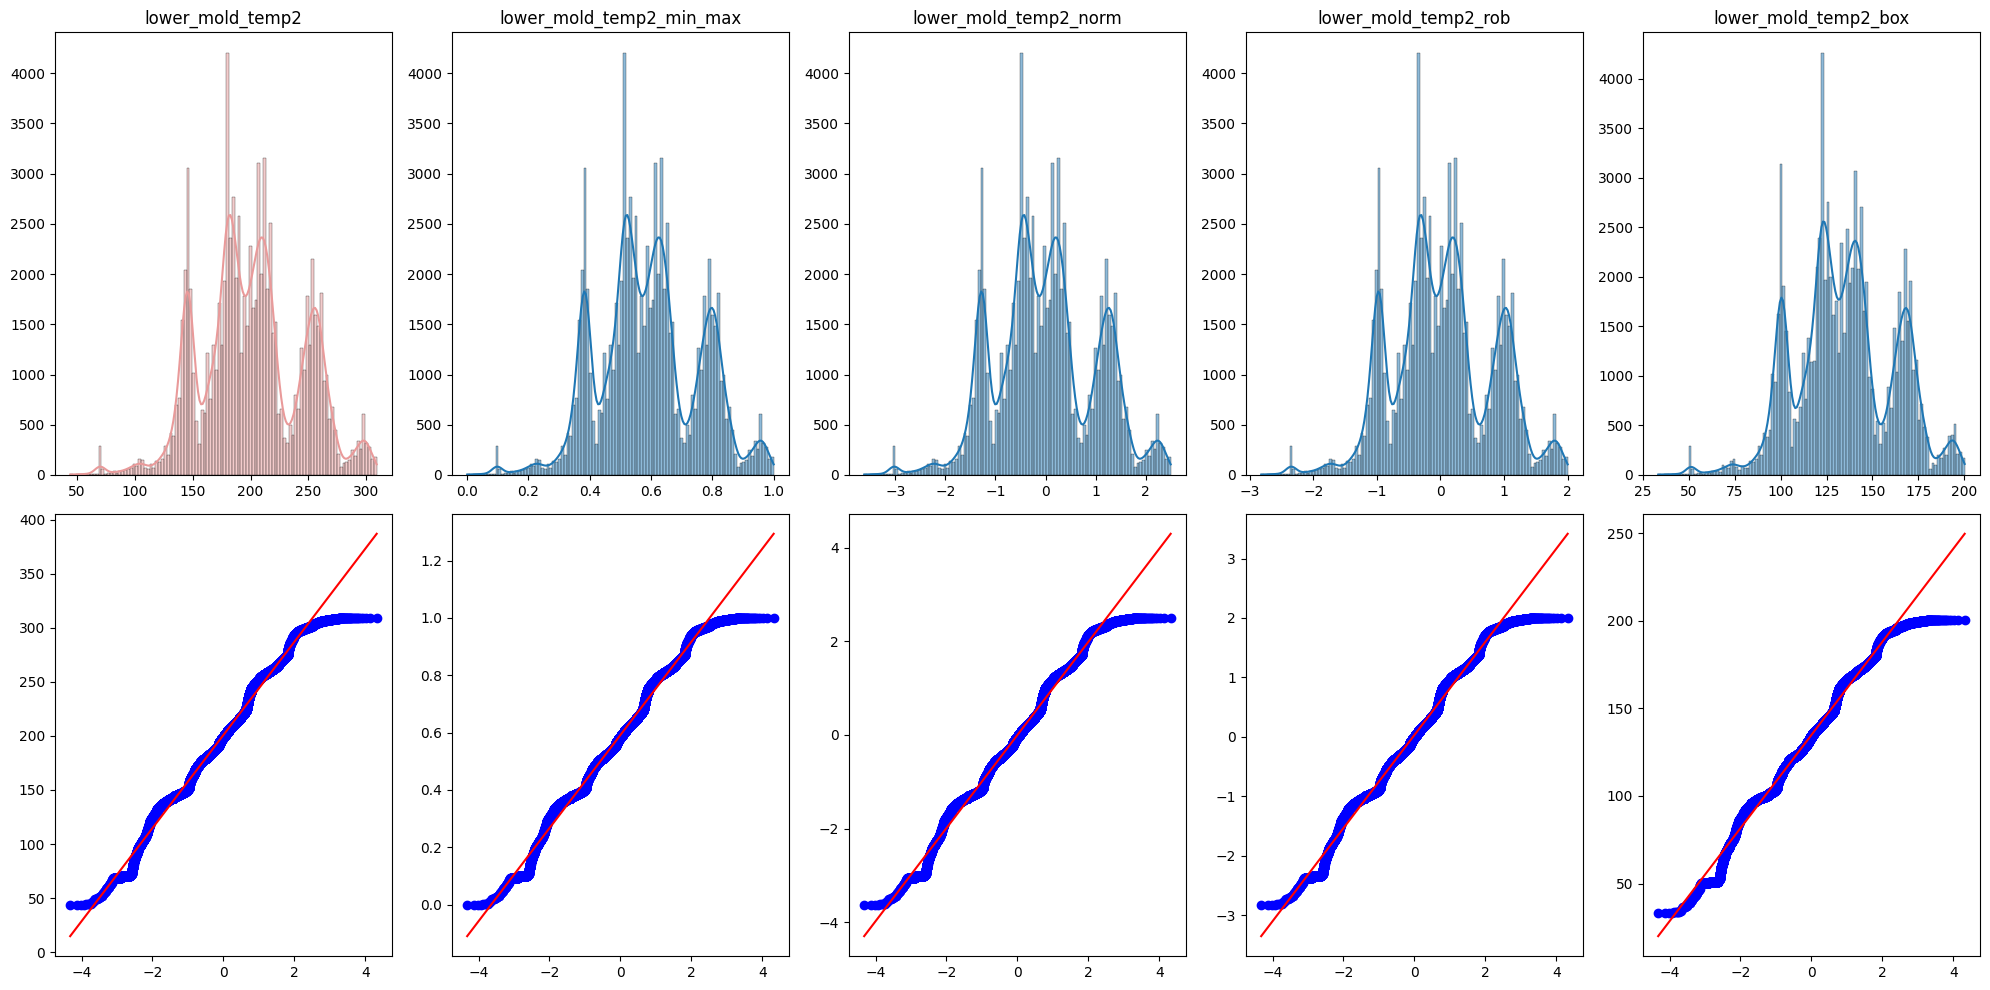

In [ ]:
get_hist_and_qq(df_filtered, 'lower_mold_temp2')

- `lower_mold_temp2` has a multi-distribution with many peaks
- There are no specific outliers
- The shape of the distribution does not change no matter which transformation method is used
- Therefore, simply select **Standardization**

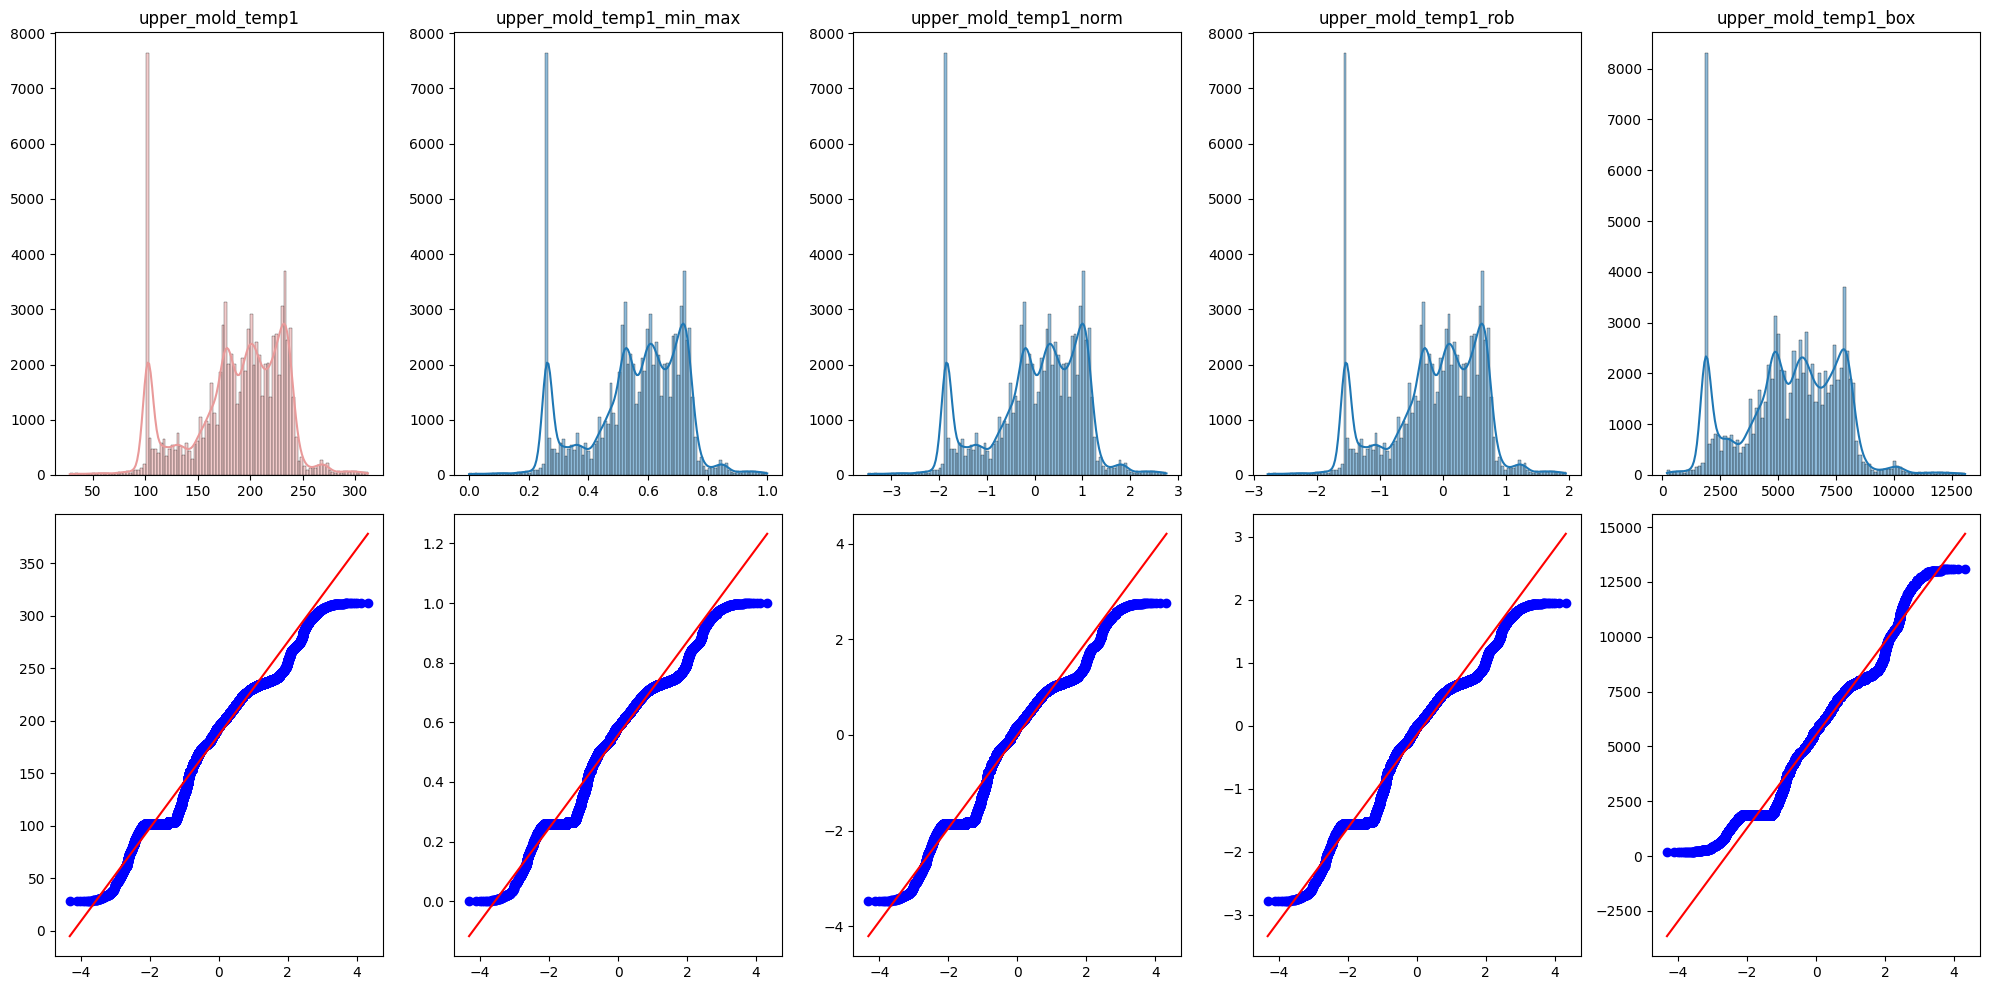

In [ ]:
get_hist_and_qq(df_filtered, 'upper_mold_temp1')

- `upper_mold_temp1` exhibits a multi-modal distribution with several peaks.  
- Based on the QQ plot, it appears to approximate a normal distribution to some extent.  
- After applying MinMax scaling, Normalization, and Robust scaling, no significant changes in the distribution were observed.  
- The Box-Cox transformation seems to merely shift the original distribution to the left.  
- No significant outliers were detected.  
- Therefore, **Standardization** is chosen as the preferred method.  

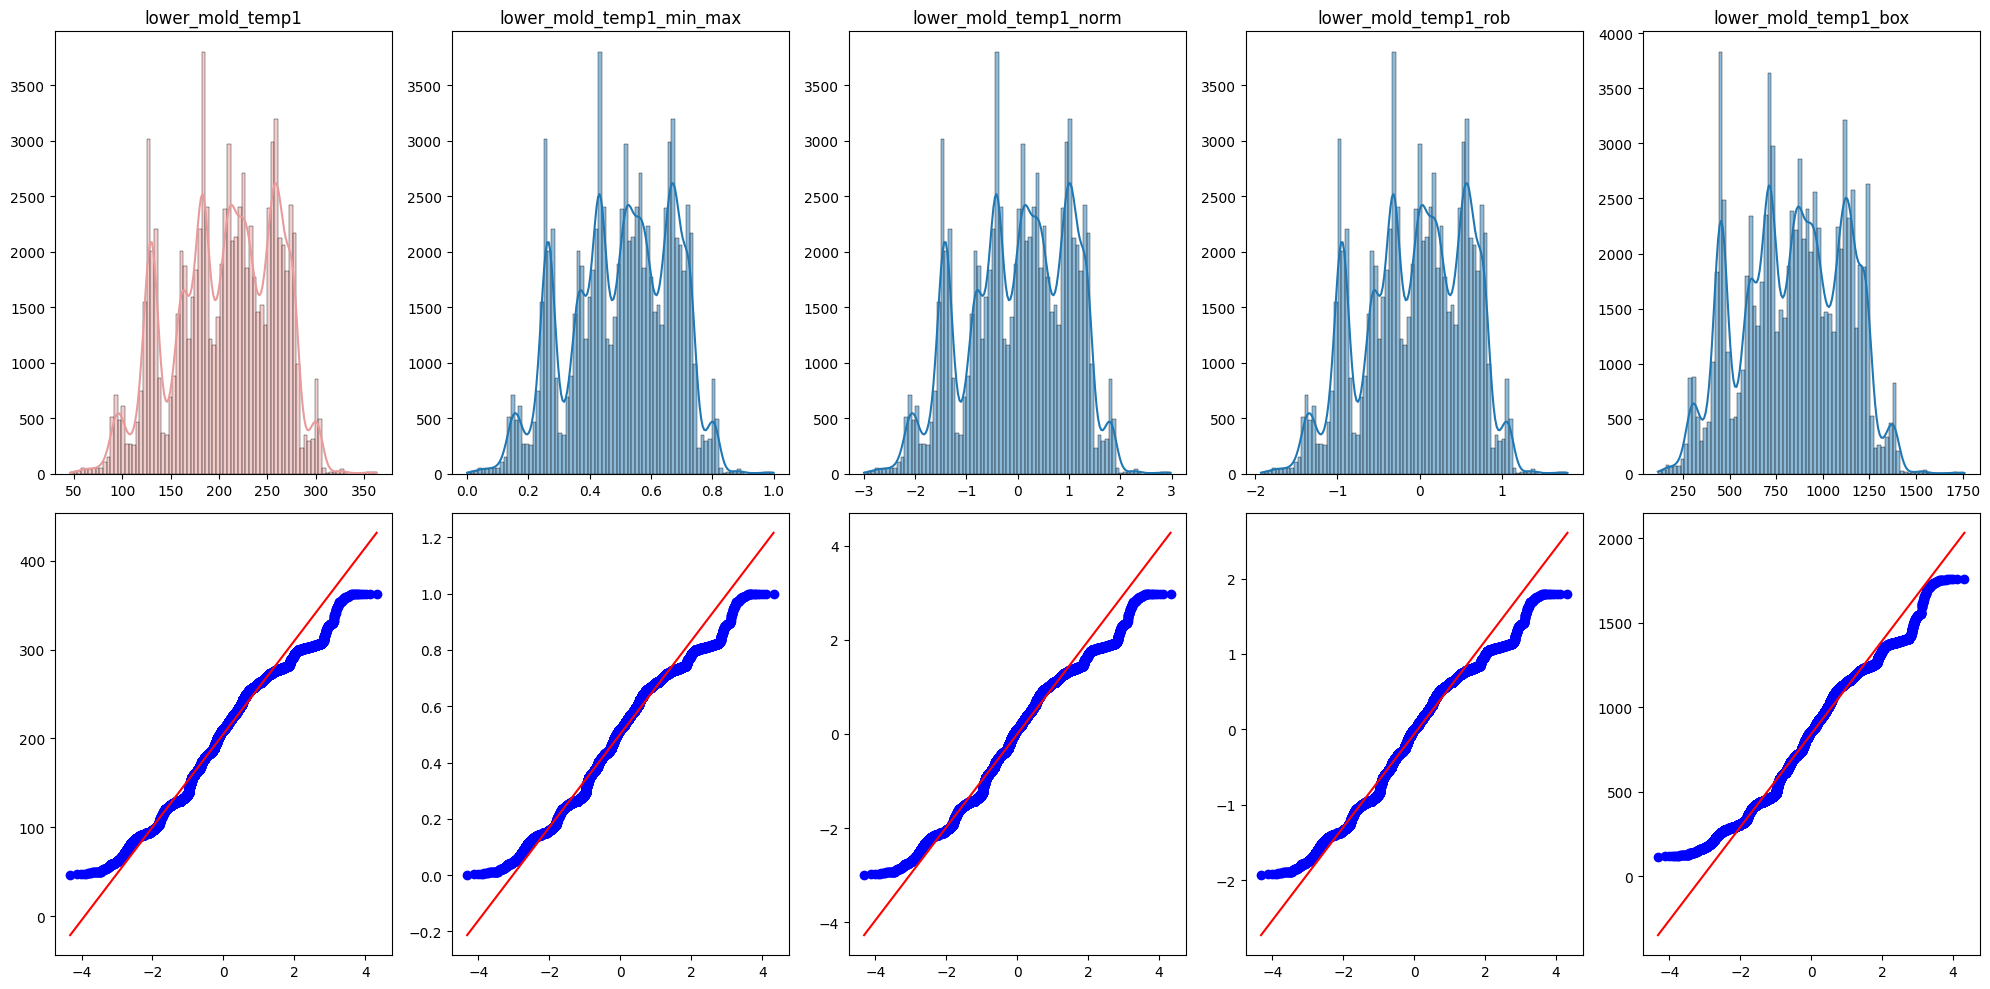

In [ ]:
get_hist_and_qq(df_filtered, 'lower_mold_temp1')

- `lower_mold_temp_1` exhibits a distribution with multiple peaks.  
- Similar to other cases, applying transformations to `lower_mold_temp_1` did not result in any significant changes to the distribution.  
- Although the Box-Cox transformation shows a different distribution and QQ plot compared to other transformations, it cannot be considered significantly better.  
- Therefore, **Standardization** is simply selected.  

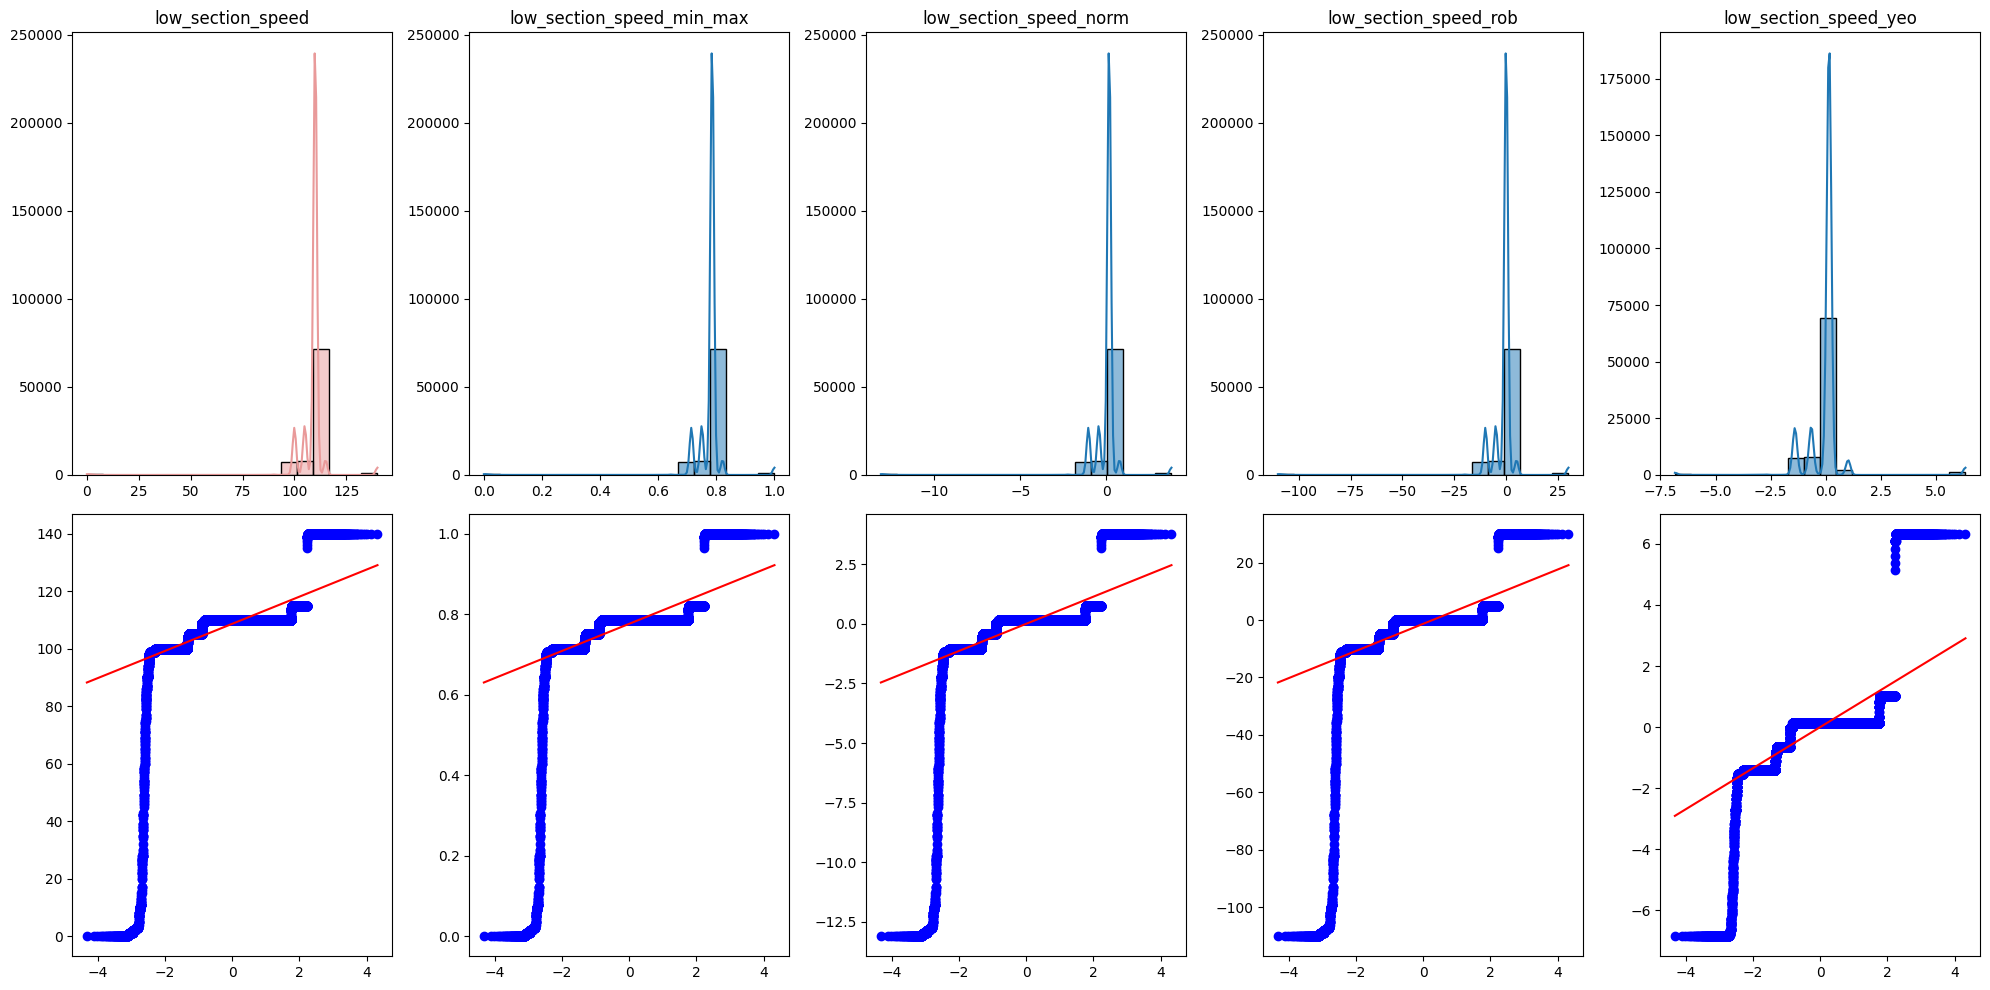

In [ ]:
get_hist_and_qq(df_filtered, 'low_section_speed')

- After applying transformations, `low_section_speed` remains almost identical to its original distribution.  
- Yeo-Johnson transformation was used instead of Box-Cox because the data contains values of 0. While the Yeo-Johnson result appears relatively closer to a normal distribution compared to other transformations, it cannot be considered significantly improved.  

### Binning low_section_speed

- With histogram, it seems that binning would be more appropriate to `low_section_speed`

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins=3
ubin_discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')  # Uniform Binning
kbin_discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans')  # Kmeans Binning
qbin_discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')  # Quantile Binning

for bin, discretizer in zip(['ubin','kbin','qbin'], [ubin_discretizer, kbin_discretizer, qbin_discretizer]):
  df_filtered[f'low_section_speed_{bin}']= discretizer.fit_transform(df_filtered[['low_section_speed']])

df_filtered


,cast_pressure,lower_mold_temp2,upper_mold_temp1,lower_mold_temp1,low_section_speed,passorfail,cast_pressure_min_max,lower_mold_temp2_min_max,upper_mold_temp1_min_max,lower_mold_temp1_min_max,...,cast_pressure_box,lower_mold_temp2_box,upper_mold_temp1_box,lower_mold_temp1_box,low_section_speed_yeo,mold_code,mold_code_ord,low_section_speed_ubin,low_section_speed_kbin,low_section_speed_qbin
90,330.0,206.0,142.0,162.0,109.0,0.0,0.958974,0.611321,0.401408,0.365931,...,8.638263e+57,138.272469,3303.800562,609.082504,-0.019326,8722,1,2.0,2.0,0.0
101,158.0,128.0,168.0,127.0,110.0,1.0,0.076923,0.316981,0.492958,0.255521,...,2.535878e+50,89.345737,4432.530430,442.117962,0.146318,8573,2,2.0,2.0,1.0
103,185.0,146.0,194.0,148.0,110.0,1.0,0.215385,0.384906,0.584507,0.321767,...,1.041303e+52,100.832746,5700.097636,540.776960,0.146318,8573,2,2.0,2.0,1.0
105,191.0,159.0,212.0,163.0,110.0,1.0,0.246154,0.433962,0.647887,0.369085,...,2.208028e+52,109.047783,6656.327620,614.034827,0.146318,8573,2,2.0,2.0,1.0
107,189.0,167.0,216.0,171.0,110.0,1.0,0.235897,0.464151,0.661972,0.394322,...,1.723253e+52,114.072447,6877.388100,653.994177,0.146318,8573,2,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,331.0,201.0,83.0,231.0,100.0,0.0,0.964103,0.592453,0.193662,0.583596,...,9.276220e+57,135.195069,1292.156191,971.412289,-1.401004,8917,4,2.0,2.0,0.0
92011,331.0,201.0,83.0,232.0,100.0,0.0,0.964103,0.592453,0.193662,0.586751,...,9.276220e+57,135.195069,1292.156191,976.947216,-1.401004,8917,4,2.0,2.0,0.0
92012,331.0,195.0,79.0,225.0,100.0,0.0,0.964103,0.569811,0.179577,0.564669,...,9.276220e+57,131.492934,1185.243935,938.361543,-1.401004,8917,4,2.0,2.0,0.0
92013,331.0,199.0,82.0,227.0,100.0,0.0,0.964103,0.584906,0.190141,0.570978,...,9.276220e+57,133.962160,1265.058412,949.348056,-1.401004,8917,4,2.0,2.0,0.0


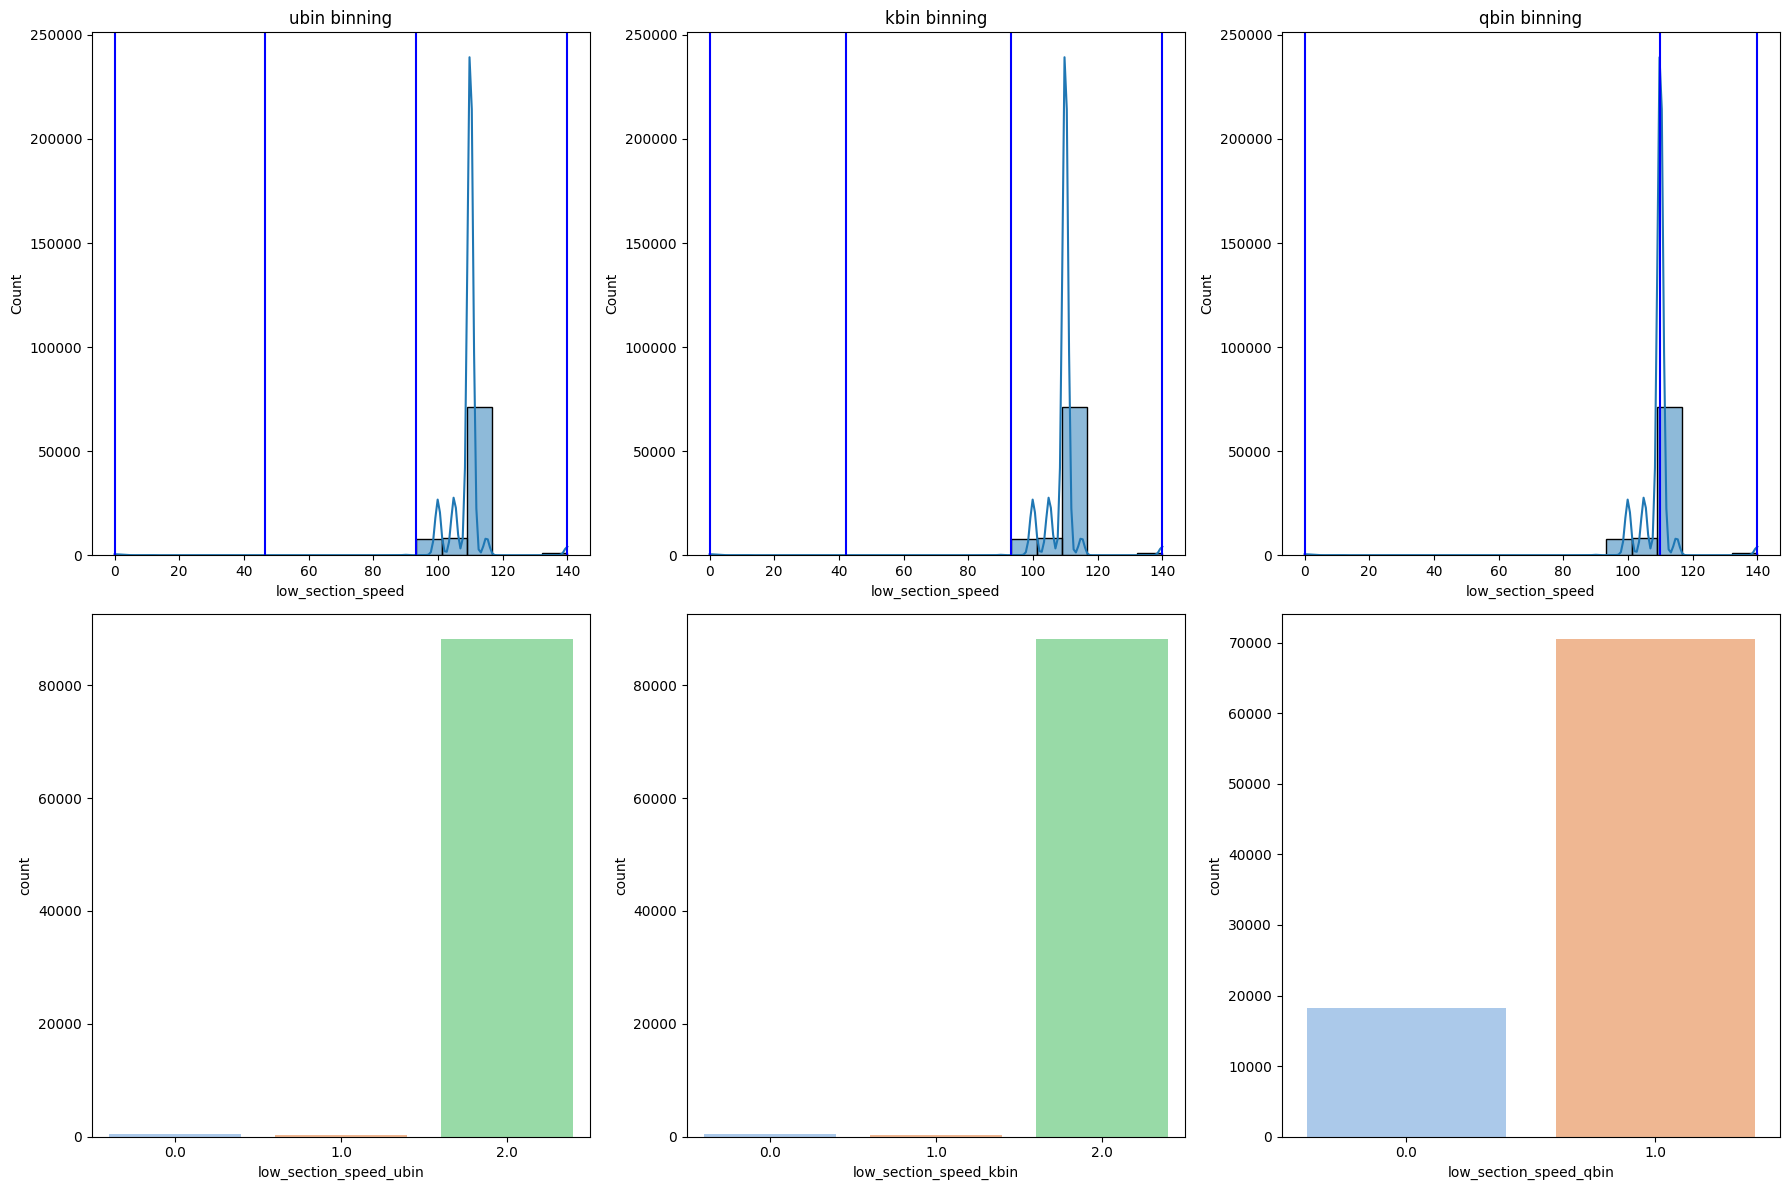

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
binning_methods = ['ubin', 'kbin', 'qbin']

for idx, bin_type in enumerate(binning_methods):
    col_name = f'low_section_speed_{bin_type}'

    # Histogram
    sns.histplot(df_filtered['low_section_speed'], ax=axes[0, idx], kde=True)
    for edge in eval(f'{bin_type}_discretizer').bin_edges_[0]:
        line = axes[0, idx].axvline(edge, color='b')
    axes[0, idx].set_title(f'{bin_type} binning')

    # Countplot
    sns.countplot(x=df_filtered[col_name], ax=axes[1, idx], palette='pastel')
    # axes[1, idx].set_title(f'{bin_type} Binning ({n_bins} bins)')

plt.tight_layout()
plt.show()

- **ubin and kbin**:  
  - Both binning methods result in an extreme concentration of data in a single bin, making them potentially unsuitable for data analysis and modeling.  
  - Particularly, ubin divides the data into equal intervals without considering the distribution, leading to excessive data concentration in certain intervals.  

- **qbin**:  
  - Since qbin sets bins based on the number of data points, it achieves a relatively balanced distribution.  
  - This method is likely more effective in avoiding bias towards specific intervals during data analysis and modeling.  


- **Overall Evaluation**:  
  - The data is heavily concentrated around specific values (e.g., 100–120), resulting in a skewed distribution.  
  - To address the issue of data imbalance, **qbin (Quantile Binning)** appears to be the most suitable method.  
  - In contrast, ubin and kbin fail to mitigate the skewed distribution, requiring caution when used in analysis and modeling.  

### Label chart

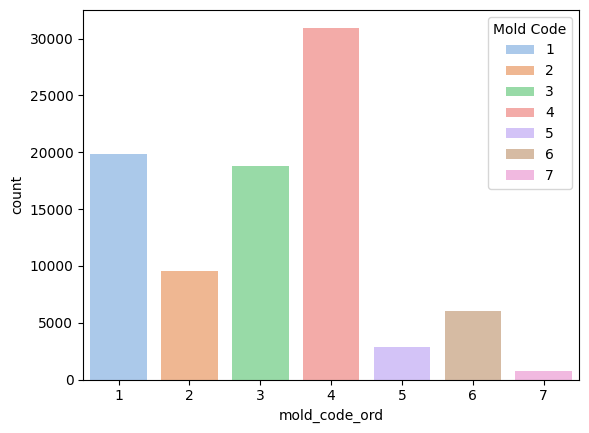

In [ ]:
df_filtered['mold_code_ord'] = df_filtered['mold_code_ord'].astype('category')
sns.countplot(x=df_filtered['mold_code_ord'], palette='pastel')
plt.legend(title='Mold Code', loc='upper right', labels=df_filtered['mold_code_ord'].unique())

- The `mold_code_ord` variable consists of **7 categories** (1, 2, 3, 4, 5, 6, 7) as categorical data.
- The distribution of the data can be summarized as follows:
  - **Mold Code 4**: This category has the highest count, with over **30,000 instances**.  
  - **Mold Code 1 and 3**: These are the second most frequent categories, each with more than **20,000 instances**.  
  - **Mold Code 2**: This category has a relatively lower count of approximately **10,000 instances**.  
  - **Mold Code 5, 6, and 7**: These categories have the lowest counts, with **Mold Code 7** being the least frequent.  

In [ ]:
import datetime
from sklearn import tree
import seaborn as sns
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from math import sqrt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report

In [ ]:
df_filtered.columns

Index(['cast_pressure', 'lower_mold_temp2', 'upper_mold_temp1',
       'lower_mold_temp1', 'low_section_speed', 'passorfail',
       'cast_pressure_min_max', 'lower_mold_temp2_min_max',
       'upper_mold_temp1_min_max', 'lower_mold_temp1_min_max',
       'low_section_speed_min_max', 'cast_pressure_norm',
       'lower_mold_temp2_norm', 'upper_mold_temp1_norm',
       'lower_mold_temp1_norm', 'low_section_speed_norm', 'cast_pressure_rob',
       'lower_mold_temp2_rob', 'upper_mold_temp1_rob', 'lower_mold_temp1_rob',
       'low_section_speed_rob', 'cast_pressure_box', 'lower_mold_temp2_box',
       'upper_mold_temp1_box', 'lower_mold_temp1_box', 'low_section_speed_yeo',
       'mold_code', 'mold_code_ord', 'low_section_speed_ubin',
       'low_section_speed_kbin', 'low_section_speed_qbin'],
      dtype='object')

In [ ]:
df_final = df_filtered[['cast_pressure_box','lower_mold_temp2_norm','upper_mold_temp1_norm','lower_mold_temp1_norm','passorfail']]
df_final.head(3)

,cast_pressure_box,lower_mold_temp2_norm,upper_mold_temp1_norm,lower_mold_temp1_norm,passorfail
90,8.638263e+57,0.119076,-0.974127,-0.810105,0.0
101,2.535878e+50,-1.681573,-0.402809,-1.470195,1.0
103,1.041303e+52,-1.266039,0.168509,-1.074141,1.0
